# Prédiction du Risque de Churn Client

**Apprentissage Supervisé — Classification Binaire avec `tidymodels`**

Master 1 Informatique

NGOM Khadim

---

## A propos de ce notebook

Ce notebook est conçu pour être exécuté sur **Google Colab avec le kernel R**. Il couvre l'intégralité du pipeline de machine learning, de l'analyse exploratoire jusqu'à l'interprétabilité des modèles.

**Pour activer le kernel R sur Google Colab :**

1. Ouvrir le notebook sur Google Colab
2. Aller dans `Exécution` > `Modifier le type d'exécution`
3. Sélectionner **R** dans le menu déroulant `Type d'exécution`
4. Cliquer sur `Enregistrer`

**Ordre d'exécution recommandé :** exécuter les cellules de haut en bas, dans l'ordre. La cellule d'installation des packages doit impérativement être exécutée en premier.

---

## Plan du notebook

1. Installation et chargement des packages
2. Chargement et découverte des données
3. Analyse exploratoire (EDA)
4. Prétraitement et ingénierie des variables
5. Modélisation et optimisation des hyperparamètres
6. Evaluation et comparaison des modèles
7. Interprétabilité (SHAP et LIME)
8. Synthèse et conclusions

---

# 1. Installation et chargement des packages

## 1.1 Installation

L'environnement Colab R ne dispose pas de tous les packages nécessaires par défaut. La cellule ci-dessous installe l'ensemble des dépendances. **Cette étape peut prendre 5 à 20 minutes** lors de la première exécution — c'est normal.

Les packages sont organisés par rôle :

- `tidyverse` : manipulation et visualisation des données
- `tidymodels` : framework de machine learning unifié
- `themis` : gestion du déséquilibre de classes (SMOTE)
- `ranger`, `xgboost`, `kernlab`, `glmnet` : moteurs des algorithmes
- `shapviz`, `lime`, `vip` : interprétabilité des modèles
- `kableExtra`, `patchwork`, `scales` : présentation des résultats

In [1]:
# Installation de tous les packages nécessaires

packages_requis <- c(
  "tidyverse", "janitor",
  "tidymodels", "themis",
  "ranger", "xgboost", "kernlab", "glmnet",
  "shapviz", "lime", "vip",
  "kableExtra", "patchwork", "scales", "sessioninfo"
)

packages_manquants <- packages_requis[!packages_requis %in% installed.packages()[, "Package"]]

if (length(packages_manquants) > 0) {
  message("Installation des packages manquants : ", paste(packages_manquants, collapse = ", "))
  install.packages(packages_manquants, repos = "https://cran.rstudio.com/", quiet = TRUE)
} else {
  message("Tous les packages sont déjà installés.")
}

Installation des packages manquants : tidymodels, themis, xgboost, shapviz, lime

also installing the dependencies ‘prodlim’, ‘ipred’, ‘recipes’, ‘rsample’, ‘tune’, ‘workflows’, ‘workflowsets’, ‘ggfittext’, ‘gggenes’




## 1.2 Chargement des packages et configuration globale

In [2]:
#  Manipulation et visualisation
library(tidyverse)
library(janitor)      # Normalisation des noms de colonnes

# Modélisation
library(tidymodels)   # Framework ML unifié
library(themis)       # Rééchantillonnage (SMOTE)
library(ranger)       # Random Forest
library(xgboost)      # Gradient Boosting
library(kernlab)      # SVM
library(glmnet)       # Régression logistique régularisée

# Interprétabilité
library(shapviz)      # Valeurs SHAP
library(lime)         # Explications locales LIME
library(vip)          # Importance des variables

# Présentation
library(kableExtra)   # Tableaux enrichis
library(patchwork)    # Composition de graphiques
library(scales)       # Formatage des axes

# Configuration globale
set.seed(2024)        # Reproductibilité
options(scipen = 999) # Désactivation de la notation scientifique

# Thème ggplot2 par défaut
theme_set(
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(color = "grey40", size = 11),
    strip.text    = element_text(face = "bold")
  )
)

message("Environnement chargé avec succès.")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.2      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.4.1      ✔ workflowsets 1.1.1 
✔ recipes      1.3.1      ✔ yardstic

---

# 2. Chargement et découverte des données

## 2.1 Source des données

Nous utilisons le dataset **IBM Telco Customer Churn**, disponible publiquement sur Kaggle. Il contient **7 043 observations et 21 variables** décrivant les clients d'un opérateur télécom américain.

Les données ont été téléchargées manuellement depuis Kaggle puis importées localement dans ce notebook.

## 2.2 Chargement

In [15]:
df_raw <- read_csv("Telco-Customer-Churn.csv") %>% clean_names()

Rows: 7043 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (17): customerID, gender, Partner, Dependents, PhoneService, MultipleLin...
dbl  (4): SeniorCitizen, tenure, MonthlyCharges, TotalCharges

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## 2.3 Aperçu général

In [16]:
# Structure du jeu de données
glimpse(df_raw)

Rows: 7,043
Columns: 21
$ customer_id       <chr> "7590-VHVEG", "5575-GNVDE", "3668-QPYBK", "7795-CFOC…
$ gender            <chr> "Female", "Male", "Male", "Male", "Female", "Female"…
$ senior_citizen    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ partner           <chr> "Yes", "No", "No", "No", "No", "No", "No", "No", "Ye…
$ dependents        <chr> "No", "No", "No", "No", "No", "No", "Yes", "No", "No…
$ tenure            <dbl> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, …
$ phone_service     <chr> "No", "Yes", "Yes", "No", "Yes", "Yes", "Yes", "No",…
$ multiple_lines    <chr> "No phone service", "No", "No", "No phone service", …
$ internet_service  <chr> "DSL", "DSL", "DSL", "DSL", "Fiber optic", "Fiber op…
$ online_security   <chr> "No", "Yes", "Yes", "Yes", "No", "No", "No", "Yes", …
$ online_backup     <chr> "Yes", "No", "Yes", "No", "No", "No", "Yes", "No", "…
$ device_protection <chr> "No", "Yes", "No", "Yes", "No", "Yes", "No", "No", "…
$ tech_support  

In [17]:
# Premières observations
head(df_raw, 6)

customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,⋯,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,⋯,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,⋯,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,⋯,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,⋯,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,⋯,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes


In [18]:
# Tableau descriptif des variables
tibble(
  Variable   = names(df_raw),
  Type       = map_chr(df_raw, ~ class(.x)[1]),
  Valeurs_NA = map_int(df_raw, ~ sum(is.na(.x))),
  N_Uniques  = map_int(df_raw, ~ n_distinct(.x)),
  Exemple    = map_chr(df_raw, ~ as.character(.x[!is.na(.x)][1]))
)

Variable,Type,Valeurs_NA,N_Uniques,Exemple
<chr>,<chr>,<int>,<int>,<chr>
customer_id,character,0,7043,7590-VHVEG
gender,character,0,2,Female
senior_citizen,numeric,0,2,0
partner,character,0,2,Yes
dependents,character,0,2,No
tenure,numeric,0,73,1
phone_service,character,0,2,No
multiple_lines,character,0,3,No phone service
internet_service,character,0,3,DSL


---

# 3. Analyse Exploratoire des Données (EDA)

L'analyse exploratoire poursuit trois objectifs :

1. Comprendre la distribution et la nature de chaque variable
2. Identifier les relations entre les prédicteurs et la variable cible
3. Détecter les anomalies, valeurs manquantes et déséquilibres à traiter

## 3.1 Distribution de la variable cible

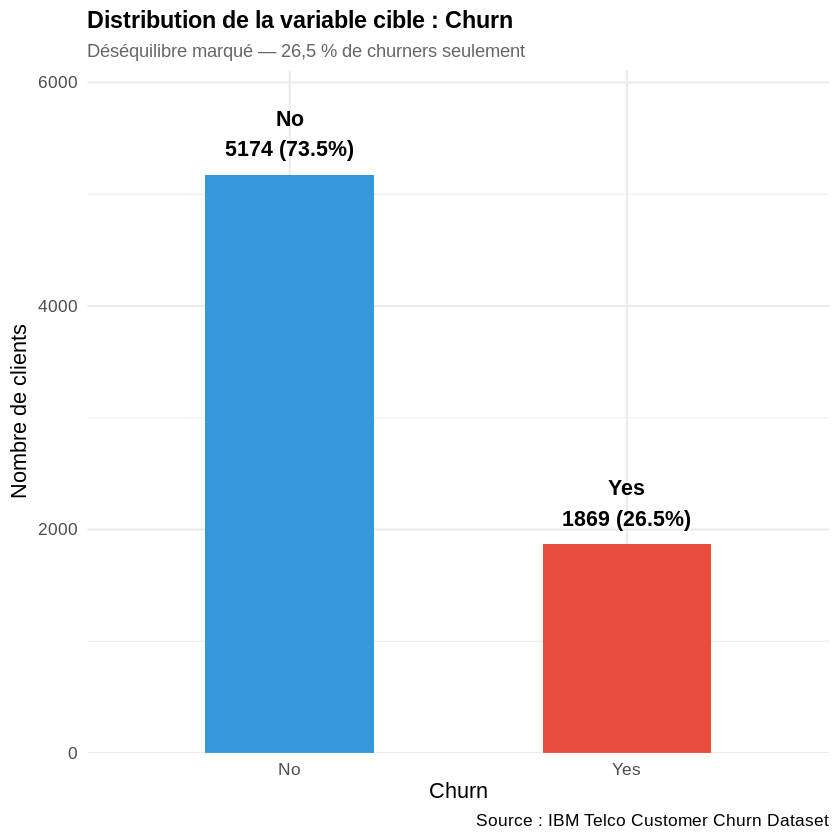

In [19]:
df_raw %>%
  count(churn) %>%
  mutate(
    proportion = n / sum(n),
    label      = paste0(churn, "\n", n, " (", percent(proportion, accuracy = 0.1), ")")
  ) %>%
  ggplot(aes(x = churn, y = n, fill = churn)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  geom_text(aes(label = label), vjust = -0.4, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("No" = "#3498DB", "Yes" = "#E74C3C")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(
    title    = "Distribution de la variable cible : Churn",
    subtitle = "Déséquilibre marqué — 26,5 % de churners seulement",
    x        = "Churn",
    y        = "Nombre de clients",
    caption  = "Source : IBM Telco Customer Churn Dataset"
  )

**Observation :** Le jeu de données est déséquilibré — seulement **26,5 %** des clients ont résilié. Sans traitement, un modèle naïf prédirait systématiquement "Non-churn" et atteindrait 73,5 % d'accuracy sans rien apprendre. Ce déséquilibre sera corrigé par **SMOTE** lors du prétraitement.

## 3.2 Distribution des variables numériques

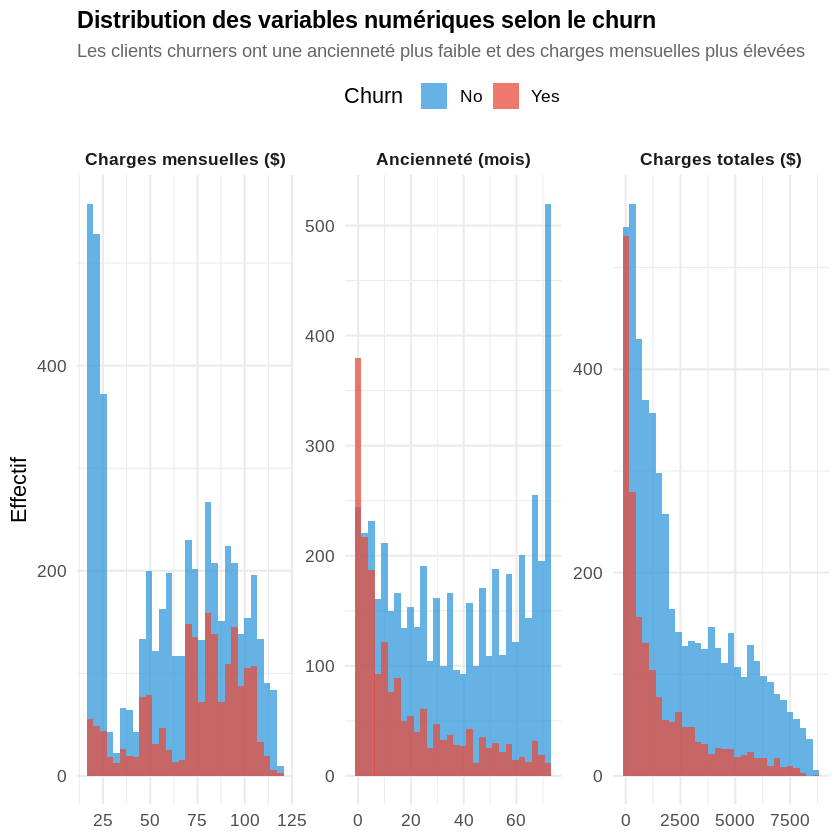

In [20]:
df_raw %>%
  select(tenure, monthly_charges, total_charges, churn) %>%
  mutate(total_charges = as.numeric(total_charges)) %>%
  pivot_longer(-churn, names_to = "variable", values_to = "valeur") %>%
  drop_na() %>%
  ggplot(aes(x = valeur, fill = churn)) +
  geom_histogram(bins = 30, alpha = 0.75, position = "identity") +
  facet_wrap(
    ~ variable, scales = "free", nrow = 1,
    labeller = labeller(variable = c(
      tenure          = "Ancienneté (mois)",
      monthly_charges = "Charges mensuelles ($)",
      total_charges   = "Charges totales ($)"
    ))
  ) +
  scale_fill_manual(
    values = c("No" = "#3498DB", "Yes" = "#E74C3C"),
    name   = "Churn"
  ) +
  labs(
    title    = "Distribution des variables numériques selon le churn",
    subtitle = "Les clients churners ont une ancienneté plus faible et des charges mensuelles plus élevées",
    x        = NULL,
    y        = "Effectif"
  ) +
  theme(legend.position = "top")

**Observations clés :**

- Les clients ayant une ancienneté faible (< 12 mois) churne bien plus souvent.
- Les churners ont des charges mensuelles légèrement plus élevées en moyenne.
- Les charges totales sont corrélées à l'ancienneté (logique), donc peu informatives seules.

## 3.3 Taux de churn par variable catégorielle

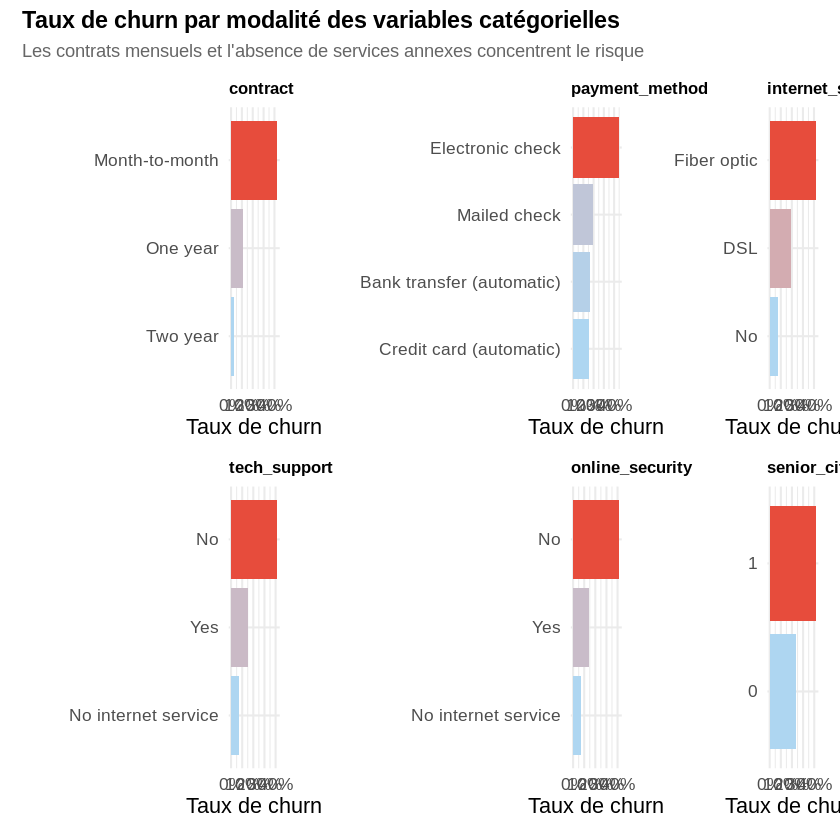

In [21]:
vars_cat <- c("contract", "payment_method", "internet_service",
              "tech_support", "online_security", "senior_citizen")

plots <- map(vars_cat, function(var) {
  df_raw %>%
    count(.data[[var]], churn) %>%
    group_by(.data[[var]]) %>%
    mutate(taux_churn = n / sum(n)) %>%
    filter(churn == "Yes") %>%
    ggplot(aes(
      x    = reorder(.data[[var]], taux_churn),
      y    = taux_churn,
      fill = taux_churn
    )) +
    geom_col(show.legend = FALSE) +
    coord_flip() +
    scale_y_continuous(labels = percent_format(accuracy = 1)) +
    scale_fill_gradient(low = "#AED6F1", high = "#E74C3C") +
    labs(title = var, x = NULL, y = "Taux de churn") +
    theme(plot.title = element_text(size = 10))
})

wrap_plots(plots, ncol = 3) +
  plot_annotation(
    title    = "Taux de churn par modalité des variables catégorielles",
    subtitle = "Les contrats mensuels et l'absence de services annexes concentrent le risque"
  )

**Observations clés :**

- Les contrats **mois par mois** affichent un taux de churn de ~43 %, contre < 3 % pour les contrats biannuels.
- L'absence de **support technique** et de **sécurité en ligne** double quasiment le risque de churn.
- Les **seniors** churne légèrement plus que la population générale.

## 3.4 Matrice de corrélation

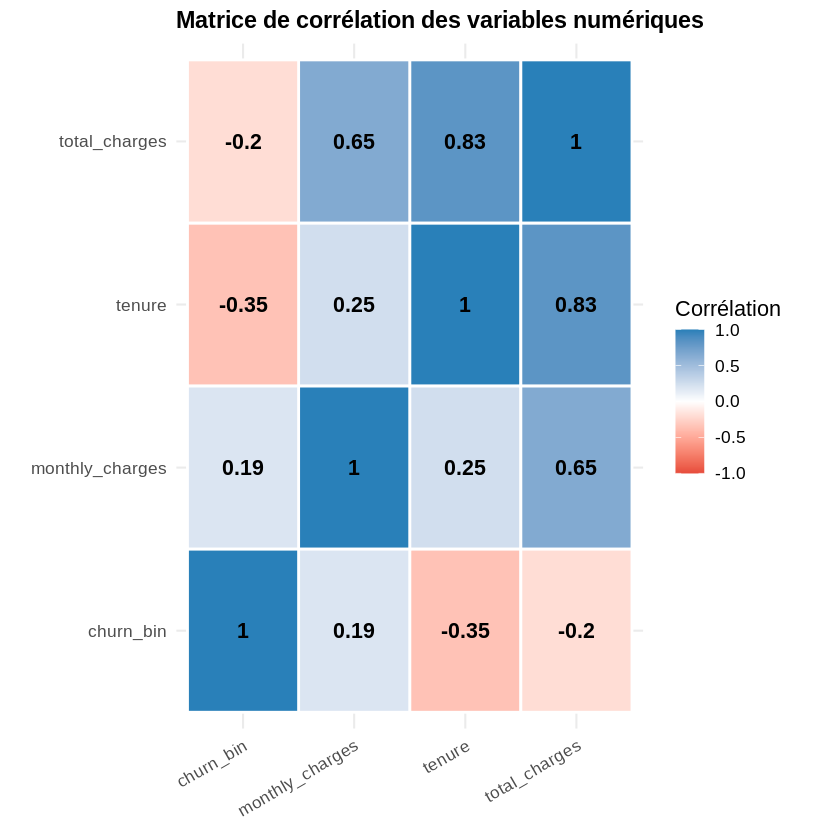

In [23]:
df_raw %>%
  mutate(
    total_charges = as.numeric(total_charges),
    churn_bin     = if_else(churn == "Yes", 1L, 0L)
  ) %>%
  select(tenure, monthly_charges, total_charges, churn_bin) %>%
  drop_na() %>%
  cor() %>%
  as.data.frame() %>%
  rownames_to_column("var1") %>%
  pivot_longer(-var1, names_to = "var2", values_to = "correlation") %>%
  ggplot(aes(x = var1, y = var2, fill = correlation)) +
  geom_tile(color = "white", linewidth = 0.8) +
  geom_text(aes(label = round(correlation, 2)), size = 4.5, fontface = "bold") +
  scale_fill_gradient2(
    low      = "#E74C3C",
    mid      = "white",
    high     = "#2980B9",
    midpoint = 0,
    limits   = c(-1, 1),
    name     = "Corrélation"
  ) +
  labs(
    title    = "Matrice de corrélation des variables numériques",
    x = NULL, y = NULL
  ) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

---

# 4. Prétraitement des Données

## 4.1 Nettoyage initial

Les opérations de nettoyage sont les suivantes :

- `total_charges` contient des espaces pour les clients récents (ancienneté = 0) qui sont convertis en `NA` lors de la conversion en numérique — ces 11 lignes seront supprimées.
- `customer_id` est un identifiant sans valeur prédictive, il est retiré.
- `senior_citizen` est encodé en 0/1 et sera converti en facteur lisible.
- La variable cible `churn` est transformée en facteur, avec "Yes" comme premier niveau (niveau positif de référence).

In [24]:
df_clean <- df_raw %>%
  mutate(total_charges  = as.numeric(total_charges)) %>%
  select(-customer_id) %>%
  mutate(
    churn          = factor(churn, levels = c("Yes", "No")),
    senior_citizen = factor(if_else(senior_citizen == 1, "Yes", "No"))
  ) %>%
  drop_na()

cat("Dimensions après nettoyage :", nrow(df_clean), "x", ncol(df_clean), "\n")
cat("Valeurs manquantes restantes :", sum(is.na(df_clean)), "\n")
cat("Distribution de la cible :\n")
print(table(df_clean$churn))

Dimensions après nettoyage : 7032 x 20 
Valeurs manquantes restantes : 0 
Distribution de la cible :

 Yes   No 
1869 5163 


## 4.2 Division train / test

La division est réalisée **avant tout prétraitement** pour éviter la fuite de données (*data leakage*) : aucune information du jeu de test ne doit influencer les transformations appliquées au jeu d'entraînement.

La **stratification** sur `churn` garantit que les proportions de la variable cible sont identiques dans les deux partitions.

In [25]:
# Division stratifiée 80 % entraînement / 20 % test
split_obj <- initial_split(df_clean, prop = 0.80, strata = churn)
df_train  <- training(split_obj)
df_test   <- testing(split_obj)

cat("Jeu d'entraînement :", nrow(df_train), "observations\n")
cat("Jeu de test        :", nrow(df_test),  "observations\n\n")

# Vérification de la stratification
bind_rows(
  df_train %>% count(churn) %>% mutate(partition = "Train", prop = percent(n / sum(n), 0.1)),
  df_test  %>% count(churn) %>% mutate(partition = "Test",  prop = percent(n / sum(n), 0.1))
) %>%
  select(partition, churn, n, prop)

Jeu d'entraînement : 5625 observations
Jeu de test        : 1407 observations



partition,churn,n,prop
<chr>,<fct>,<int>,<chr>
Train,Yes,1495,26.6%
Train,No,4130,73.4%
Test,Yes,374,26.6%
Test,No,1033,73.4%


## 4.3 Construction de la recette de prétraitement

La `recipe` de `tidymodels` encapsule toutes les transformations dans un objet reproductible. Les paramètres sont appris **uniquement sur le jeu d'entraînement** et appliqués ensuite au jeu de test, sans fuite.

**Etapes de la recette :**

1. **Imputation par la médiane** — pour les rares valeurs manquantes numériques résiduelles
2. **Encodage one-hot** — variables catégorielles transformées en indicatrices binaires
3. **Suppression variance nulle** — colonnes constantes après encodage supprimées
4. **Normalisation** — centrage et réduction indispensables pour la régression logistique et le SVM
5. **SMOTE** — génération synthétique d'observations de la classe minoritaire

In [26]:
recette_base <- recipe(churn ~ ., data = df_train) %>%
  step_impute_median(all_numeric_predictors()) %>%
  step_dummy(all_nominal_predictors(), one_hot = FALSE) %>%
  step_nzv(all_predictors()) %>%
  step_normalize(all_numeric_predictors()) %>%
  step_smote(churn, over_ratio = 0.8, seed = 2024)

# Résumé des étapes
summary(recette_base)

ERROR while rich displaying an object: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 3, 2

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         re

**Note sur SMOTE :** *Synthetic Minority Over-sampling Technique* génère des observations synthétiques pour la classe minoritaire (churners) en interpolant entre des points réels proches dans l'espace des variables. Le paramètre `over_ratio = 0.8` signifie que la classe minoritaire atteindra 80 % de la taille de la classe majoritaire après rééchantillonnage. SMOTE est appliqué **uniquement sur le jeu d'entraînement**, jamais sur le jeu de test.

---

# 5. Modélisation

## 5.1 Validation croisée

La **validation croisée à 5 plis stratifiée** est utilisée pour estimer les performances des modèles et optimiser leurs hyperparamètres de manière robuste, sans toucher au jeu de test.

In [27]:
cv_folds <- vfold_cv(df_train, v = 5, strata = churn, repeats = 1)
cat("Validation croisée configurée :", nrow(cv_folds), "plis\n")

Validation croisée configurée : 5 plis


## 5.2 Définition des modèles

Quatre algorithmes sont comparés. Les hyperparamètres marqués `tune()` seront optimisés automatiquement.

In [28]:
# Régression Logistique avec régularisation Lasso
spec_logit <- logistic_reg(penalty = tune(), mixture = 1) %>%
  set_engine("glmnet") %>%
  set_mode("classification")

# Random Forest
spec_rf <- rand_forest(mtry = tune(), trees = 500, min_n = tune()) %>%
  set_engine("ranger", importance = "impurity") %>%
  set_mode("classification")

# XGBoost
spec_xgb <- boost_tree(
  trees          = 500,
  tree_depth     = tune(),
  learn_rate     = tune(),
  loss_reduction = tune()
) %>%
  set_engine("xgboost") %>%
  set_mode("classification")

# SVM à noyau radial (RBF)
spec_svm <- svm_rbf(cost = tune(), rbf_sigma = tune()) %>%
  set_engine("kernlab") %>%
  set_mode("classification")

message("4 spécifications de modèles définies.")

4 spécifications de modèles définies.



## 5.3 Construction des workflows

Un `workflow` associe une recette de prétraitement à une spécification de modèle. Cette approche garantit que les transformations sont appliquées de manière cohérente à chaque pli de la validation croisée.

In [29]:
wf_logit <- workflow() %>% add_recipe(recette_base) %>% add_model(spec_logit)
wf_rf    <- workflow() %>% add_recipe(recette_base) %>% add_model(spec_rf)
wf_xgb   <- workflow() %>% add_recipe(recette_base) %>% add_model(spec_xgb)
wf_svm   <- workflow() %>% add_recipe(recette_base) %>% add_model(spec_svm)

message("4 workflows créés.")

4 workflows créés.



## 5.4 Optimisation des hyperparamètres

La recherche est conduite par **grille aléatoire** (`grid_random`), plus efficace que la grille exhaustive pour les espaces multi-dimensionnels. La métrique de sélection est l'**AUC-ROC**, robuste au déséquilibre de classes.

### Régression Logistique

→ A | warning: While computing binary `precision()`, no predicted events were detected (i.e.
               `true_positive + false_positive = 0`).
               Precision is undefined in this case, and `NA` will be returned.
               Note that 299 true event(s) actually occurred for the problematic event level,
               Yes

There were issues with some computations   A: x8

There were issues with some computations   A: x16

There were issues with some computations   A: x24

There were issues with some computations   A: x32

There were issues with some computations   A: x40

There were issues with some computations   A: x40





Meilleur penalty (Logit) : 0.000428 


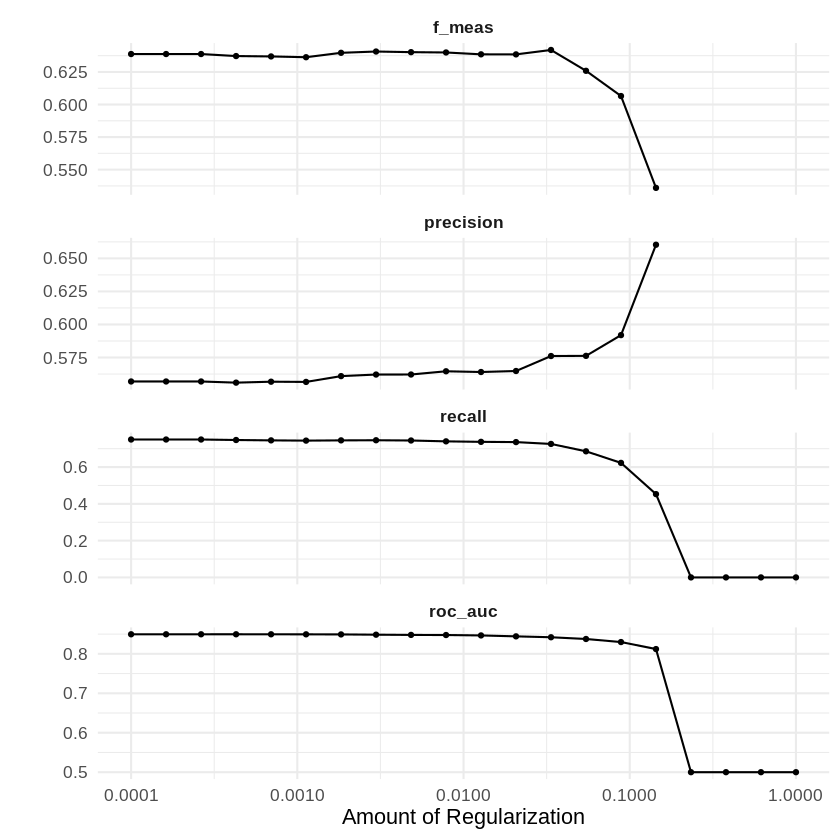

In [30]:
grille_logit <- grid_regular(penalty(range = c(-4, 0)), levels = 20)

res_logit <- tune_grid(
  wf_logit,
  resamples = cv_folds,
  grid      = grille_logit,
  metrics   = metric_set(roc_auc, f_meas, precision, recall),
  control   = control_grid(save_pred = TRUE, verbose = FALSE)
)

best_logit <- select_best(res_logit, metric = "roc_auc")
cat("Meilleur penalty (Logit) :", round(best_logit$penalty, 6), "\n")
autoplot(res_logit)

### Random Forest

Meilleur mtry (RF) : 3 | min_n : 13 


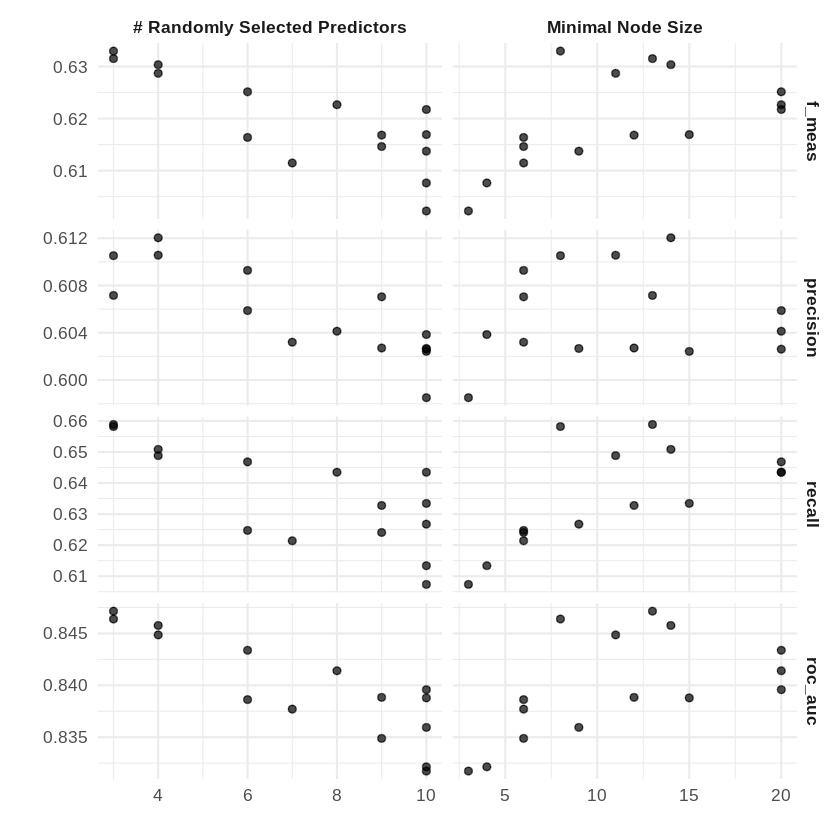

In [31]:
grille_rf <- grid_random(
  mtry(range  = c(3, 10)),
  min_n(range = c(2, 20)),
  size = 15
)

res_rf <- tune_grid(
  wf_rf,
  resamples = cv_folds,
  grid      = grille_rf,
  metrics   = metric_set(roc_auc, f_meas, precision, recall),
  control   = control_grid(save_pred = TRUE, verbose = FALSE)
)

best_rf <- select_best(res_rf, metric = "roc_auc")
cat("Meilleur mtry (RF) :", best_rf$mtry, "| min_n :", best_rf$min_n, "\n")
autoplot(res_rf)

### XGBoost

Meilleur tree_depth : 3 | learn_rate : 0.0117 


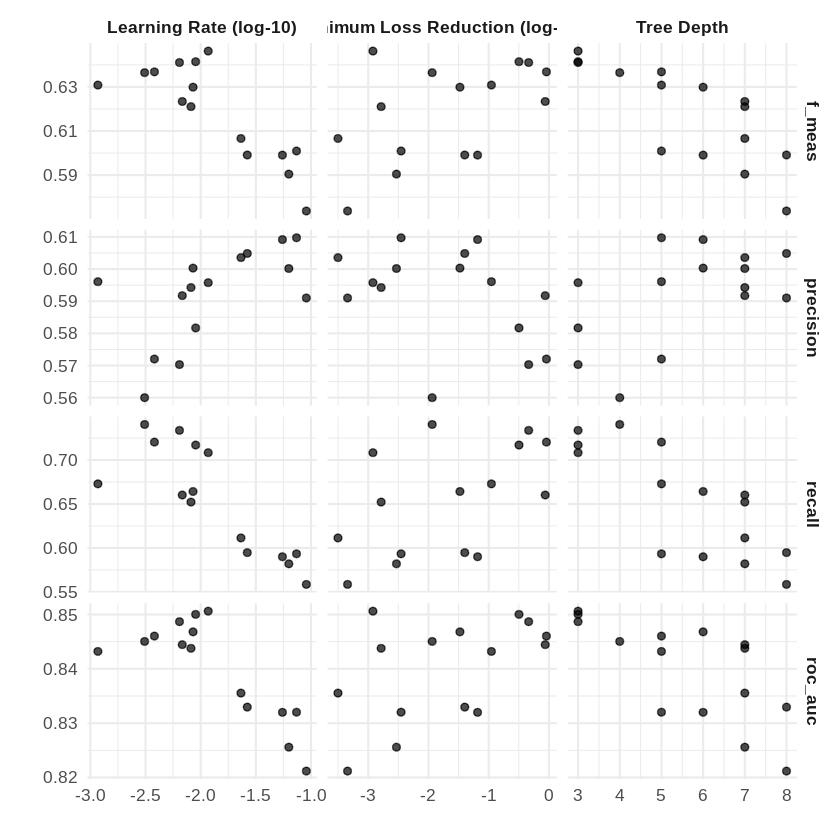

In [32]:
grille_xgb <- grid_random(
  tree_depth(range     = c(3, 8)),
  learn_rate(range     = c(-3, -1)),
  loss_reduction(range = c(-5, 0)),
  size = 15
)

res_xgb <- tune_grid(
  wf_xgb,
  resamples = cv_folds,
  grid      = grille_xgb,
  metrics   = metric_set(roc_auc, f_meas, precision, recall),
  control   = control_grid(save_pred = TRUE, verbose = FALSE)
)

best_xgb <- select_best(res_xgb, metric = "roc_auc")
cat("Meilleur tree_depth :", best_xgb$tree_depth,
    "| learn_rate :", round(best_xgb$learn_rate, 5), "\n")
autoplot(res_xgb)

### SVM

Meilleur cost : 1.2389 | rbf_sigma : 0.000966 


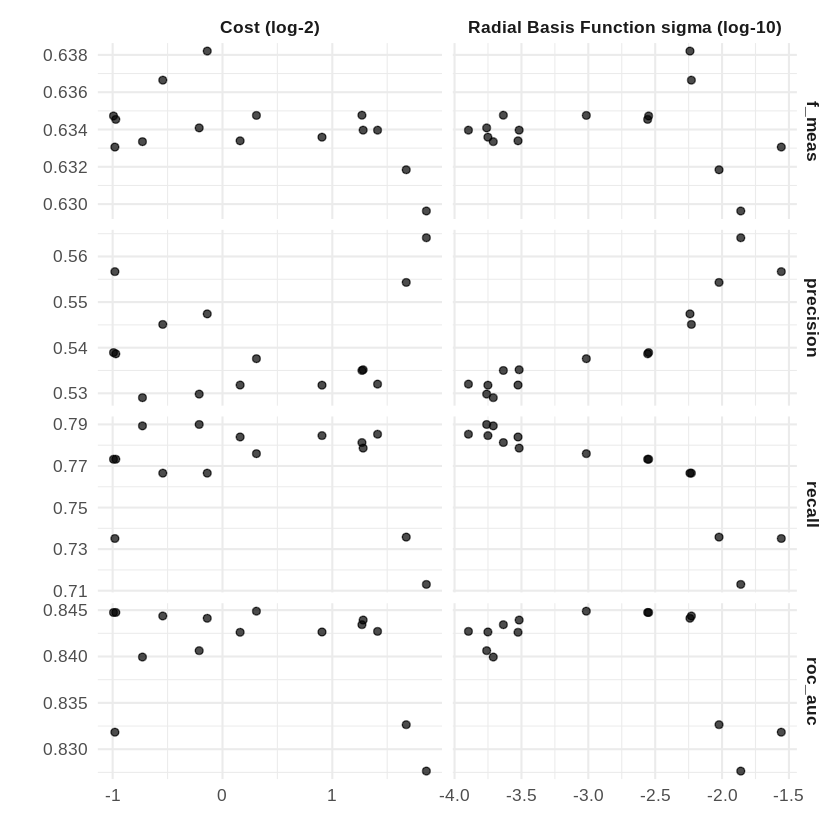

In [33]:
grille_svm <- grid_random(
  cost(range      = c(-1, 2)),
  rbf_sigma(range = c(-4, -1)),
  size = 15
)

res_svm <- tune_grid(
  wf_svm,
  resamples = cv_folds,
  grid      = grille_svm,
  metrics   = metric_set(roc_auc, f_meas, precision, recall),
  control   = control_grid(save_pred = TRUE, verbose = FALSE)
)

best_svm <- select_best(res_svm, metric = "roc_auc")
cat("Meilleur cost :", round(best_svm$cost, 4),
    "| rbf_sigma :", round(best_svm$rbf_sigma, 6), "\n")
autoplot(res_svm)

## 5.5 Finalisation et entraînement final

Les meilleurs hyperparamètres sont fixés dans chaque workflow, puis chaque modèle est entraîné sur **l'intégralité du jeu d'entraînement**.

In [34]:
wf_final_logit <- finalize_workflow(wf_logit, best_logit)
wf_final_rf    <- finalize_workflow(wf_rf,    best_rf)
wf_final_xgb   <- finalize_workflow(wf_xgb,  best_xgb)
wf_final_svm   <- finalize_workflow(wf_svm,  best_svm)

fit_logit <- fit(wf_final_logit, data = df_train)
fit_rf    <- fit(wf_final_rf,    data = df_train)
fit_xgb   <- fit(wf_final_xgb,  data = df_train)
fit_svm   <- fit(wf_final_svm,  data = df_train)

message("Tous les modèles ont été entraînés avec succès.")

Tous les modèles ont été entraînés avec succès.



---

# 6. Evaluation des Modèles

L'évaluation est réalisée **uniquement sur le jeu de test**, qui n'a participé à aucune étape précédente. C'est la seule estimation honnête des performances en généralisation.

## 6.1 Prédictions sur le jeu de test

In [35]:
# Fonction utilitaire : prédictions classes + probabilités
evaluer_modele <- function(fit_obj, nom_modele) {
  pred_classe <- predict(fit_obj, df_test)
  pred_proba  <- predict(fit_obj, df_test, type = "prob")
  bind_cols(df_test %>% select(churn), pred_classe, pred_proba) %>%
    mutate(modele = nom_modele)
}

preds_logit <- evaluer_modele(fit_logit, "Régression Logistique")
preds_rf    <- evaluer_modele(fit_rf,    "Random Forest")
preds_xgb   <- evaluer_modele(fit_xgb,  "XGBoost")
preds_svm   <- evaluer_modele(fit_svm,  "SVM (RBF)")

preds_all <- bind_rows(preds_logit, preds_rf, preds_xgb, preds_svm)
message("Prédictions générées pour les 4 modèles.")

Prédictions générées pour les 4 modèles.



## 6.2 Tableau comparatif des métriques

In [36]:
metriques <- preds_all %>%
  group_by(modele) %>%
  summarise(
    AUC_ROC   = roc_auc_vec(truth = churn, estimate = .pred_Yes),
    F1_Score  = f_meas_vec(truth = churn, estimate = .pred_class),
    Precision = precision_vec(truth = churn, estimate = .pred_class),
    Rappel    = recall_vec(truth = churn, estimate = .pred_class),
    Accuracy  = accuracy_vec(truth = churn, estimate = .pred_class),
    .groups   = "drop"
  ) %>%
  arrange(desc(AUC_ROC))

metriques %>%
  mutate(across(where(is.numeric), ~ round(.x, 4)))

modele,AUC_ROC,F1_Score,Precision,Rappel,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGBoost,0.8319,0.6083,0.5580,0.6684,0.7711
Régression Logistique,0.8268,0.5955,0.5178,0.7005,0.7470
Random Forest,0.8263,0.5773,0.5526,0.6043,0.7647
SVM (RBF),0.8179,0.5972,0.5027,0.7353,0.7363


## 6.3 Courbes ROC comparatives

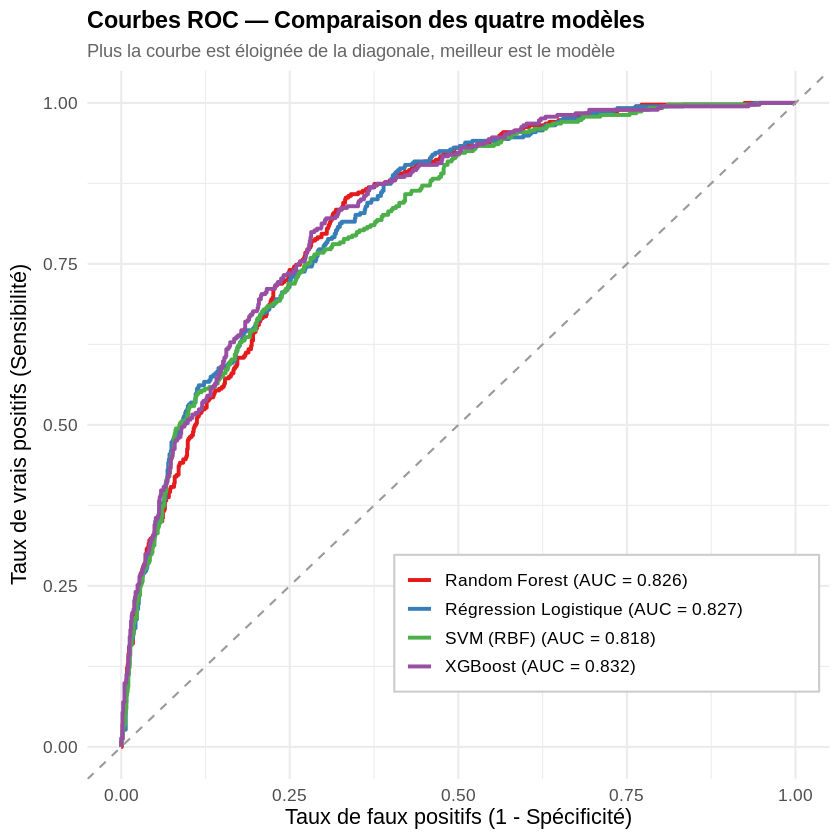

In [37]:
roc_data <- preds_all %>%
  group_by(modele) %>%
  roc_curve(truth = churn, .pred_Yes) %>%
  ungroup()

roc_labels <- metriques %>%
  mutate(label = paste0(modele, " (AUC = ", round(AUC_ROC, 3), ")")) %>%
  select(modele, label)

roc_data %>%
  left_join(roc_labels, by = "modele") %>%
  ggplot(aes(x = 1 - specificity, y = sensitivity, color = label)) +
  geom_path(linewidth = 1.1) +
  geom_abline(linetype = "dashed", color = "grey60") +
  scale_color_brewer(palette = "Set1", name = NULL) +
  labs(
    title    = "Courbes ROC — Comparaison des quatre modèles",
    subtitle = "Plus la courbe est éloignée de la diagonale, meilleur est le modèle",
    x        = "Taux de faux positifs (1 - Spécificité)",
    y        = "Taux de vrais positifs (Sensibilité)"
  ) +
  theme(legend.position = c(0.70, 0.22),
        legend.background = element_rect(fill = "white", color = "grey80"))

## 6.4 Matrices de confusion

In [38]:
preds_all %>%
  group_by(modele) %>%
  conf_mat(truth = churn, estimate = .pred_class) %>%
  mutate(tidied = map(conf_mat, tidy)) %>%
  unnest(tidied) %>%
  ggplot(aes(x = col, y = row, fill = value)) +
  geom_tile(color = "white") +
  geom_text(aes(label = value), size = 5.5, fontface = "bold", color = "white") +
  facet_wrap(~ modele, nrow = 2) +
  scale_fill_gradient(low = "#AED6F1", high = "#1A5276", name = "Effectif") +
  labs(
    title    = "Matrices de confusion par modèle",
    subtitle = "Ligne = Valeur réelle | Colonne = Valeur prédite",
    x        = "Classe prédite",
    y        = "Classe réelle"
  )

Don't know how to automatically pick scale for object of type <function>.
Defaulting to continuous.
Don't know how to automatically pick scale for object of type <function>.
Defaulting to continuous.
ERROR while rich displaying an object: Error in `geom_tile()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! Aesthetics are not valid data columns.
✖ The following aesthetics are invalid:
• `x = col`
• `y = row`
ℹ Did you mistype the name of a data column or forget to add `after_stat()`?

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, c

---

# 7. Interprétabilité des Modèles

L'interprétabilité est une exigence croissante en entreprise, notamment pour justifier les décisions automatisées auprès des équipes métier et réglementaires. On distingue deux niveaux :

- **Interprétabilité globale** : quelles variables influencent le modèle sur l'ensemble des données ?
- **Interprétabilité locale** : pourquoi le modèle a-t-il prédit X pour ce client spécifique ?

## 7.1 Importance des variables — Random Forest

L'importance par impureté de Gini mesure la réduction moyenne de l'impureté apportée par chaque variable sur l'ensemble des arbres.

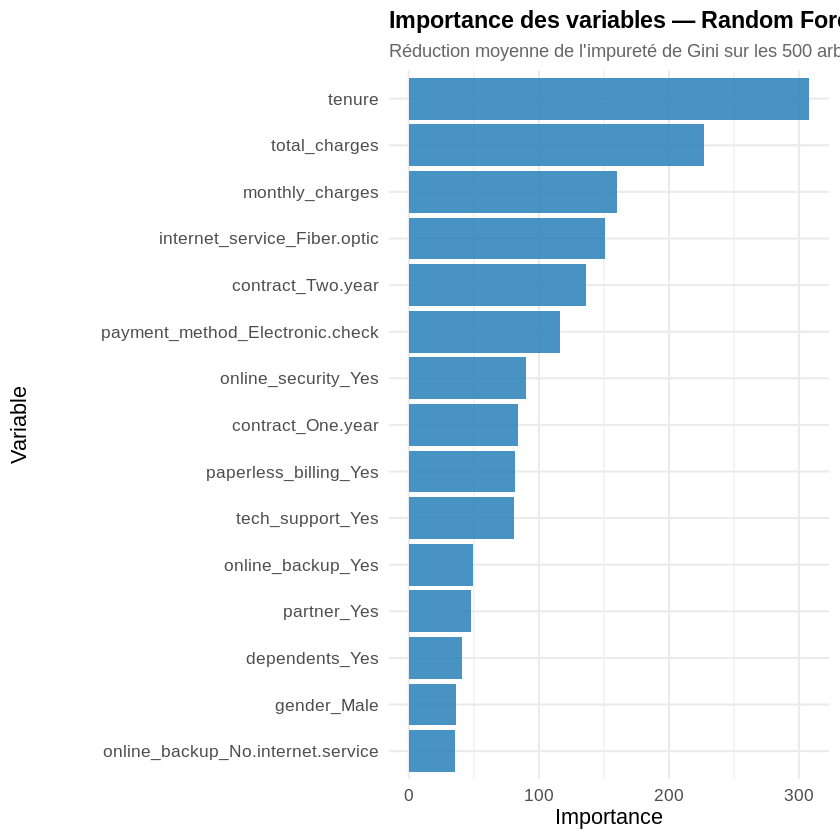

In [41]:
fit_rf %>%
  extract_fit_parsnip() %>%
  vip(
    num_features = 15,
    aesthetics   = list(fill = "#2980B9", alpha = 0.85)
  ) +
  labs(
    title    = "Importance des variables — Random Forest",
    subtitle = "Réduction moyenne de l'impureté de Gini sur les 500 arbres",
    x        = "Variable",
    y        = "Importance"
  )

## 7.2 Valeurs SHAP — XGBoost

Les valeurs SHAP (*SHapley Additive exPlanations*) offrent une décomposition **théoriquement fondée** de la contribution de chaque variable à la prédiction. Elles reposent sur la théorie des jeux coopératifs et vérifient des propriétés d'équité importantes (efficacité, symétrie, linéarité).

### Importance globale (mean |SHAP|)

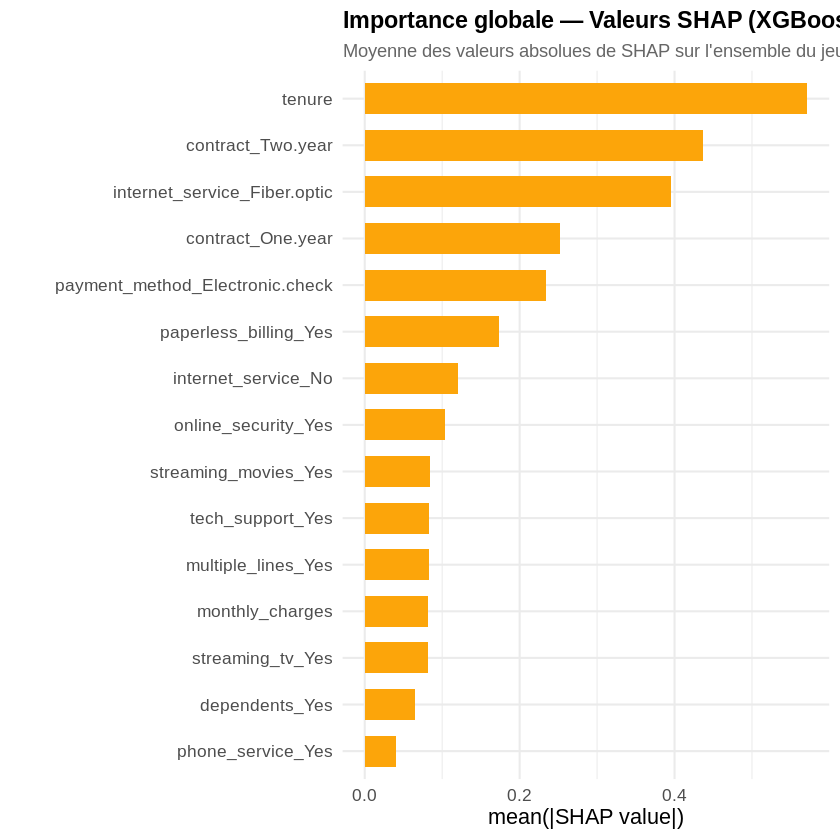

In [42]:
# Extraction du modèle XGBoost brut et de la recette entraînée
xgb_fit      <- fit_xgb %>% extract_fit_engine()
recette_prep <- fit_xgb %>% extract_recipe()

# Matrice de features prétraitées sur le jeu d'entraînement
X_train_prep <- bake(
  recette_prep,
  new_data    = df_train,
  all_predictors(),
  composition = "matrix"
)

# Calcul des valeurs SHAP
shap_obj <- shapviz(xgb_fit, X_pred = X_train_prep)

# Graphique : importance globale
sv_importance(shap_obj, kind = "bar", max_display = 15) +
  labs(
    title    = "Importance globale — Valeurs SHAP (XGBoost)",
    subtitle = "Moyenne des valeurs absolues de SHAP sur l'ensemble du jeu d'entraînement"
  )

### Distribution des valeurs SHAP (Beeswarm)

Ce graphique montre non seulement l'importance de chaque variable, mais aussi le **sens de son effet** : rouge = valeur élevée de la variable, bleu = valeur faible. Un point à droite de l'axe zéro signifie que la variable pousse la prédiction vers le churn.

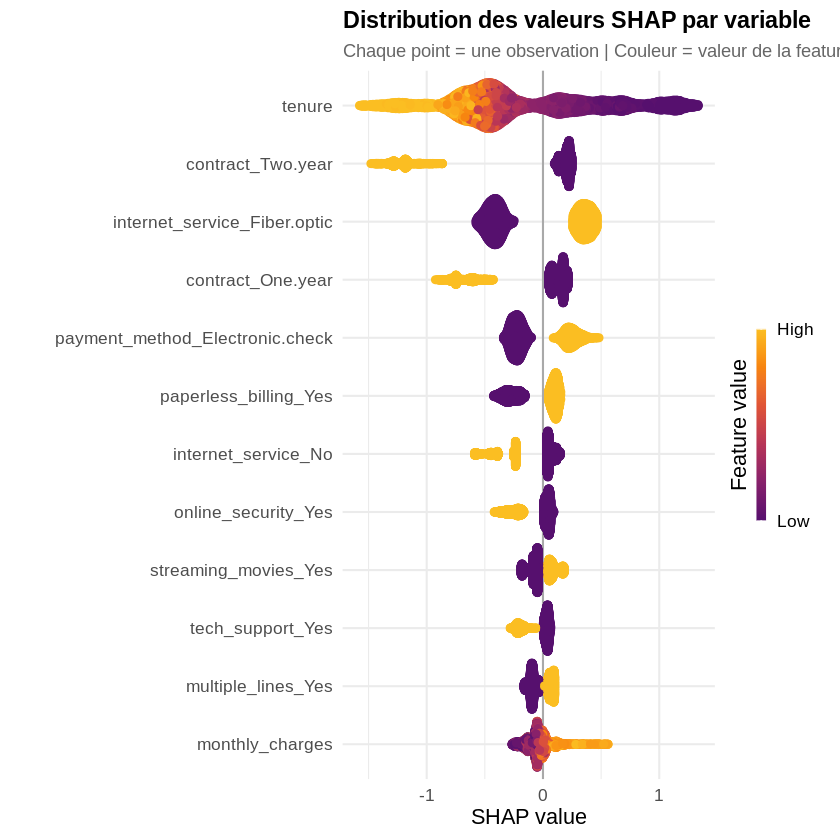

In [43]:
sv_importance(shap_obj, kind = "beeswarm", max_display = 12) +
  labs(
    title    = "Distribution des valeurs SHAP par variable",
    subtitle = "Chaque point = une observation | Couleur = valeur de la feature (rouge = élevée)"
  )

## 7.3 Explications locales — LIME

LIME (*Local Interpretable Model-agnostic Explanations*) explique la prédiction du modèle pour **une observation individuelle** en ajustant un modèle linéaire interprétable dans le voisinage local de cette observation.

Trois profils clients sont analysés : un churner quasi-certain, un cas limite, et un client très fidèle.

In [44]:
# Sélection de 3 clients représentatifs
idx_certain   <- which(preds_xgb$.pred_Yes > 0.85)[1]
idx_limite    <- which(preds_xgb$.pred_Yes > 0.45 & preds_xgb$.pred_Yes < 0.55)[1]
idx_non_churn <- which(preds_xgb$.pred_Yes < 0.10)[1]

clients_cibles <- df_test[c(idx_certain, idx_limite, idx_non_churn), ] %>%
  select(-churn)

cat("Probabilités de churn des 3 clients sélectionnés :\n")
cat("  Churner certain  :", round(preds_xgb$.pred_Yes[idx_certain],   3), "\n")
cat("  Cas limite       :", round(preds_xgb$.pred_Yes[idx_limite],     3), "\n")
cat("  Non-churner      :", round(preds_xgb$.pred_Yes[idx_non_churn],  3), "\n")

Probabilités de churn des 3 clients sélectionnés :
  Churner certain  : 0.883 
  Cas limite       : 0.527 
  Non-churner      : 0.038 


---

# 8. Synthèse et Conclusions

## 8.1 Tableau de synthèse des performances

In [46]:
metriques %>%
  mutate(across(where(is.numeric), ~ round(.x, 4))) %>%
  arrange(desc(AUC_ROC))

modele,AUC_ROC,F1_Score,Precision,Rappel,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XGBoost,0.8319,0.6083,0.5580,0.6684,0.7711
Régression Logistique,0.8268,0.5955,0.5178,0.7005,0.7470
Random Forest,0.8263,0.5773,0.5526,0.6043,0.7647
SVM (RBF),0.8179,0.5972,0.5027,0.7353,0.7363


## 8.2 Conclusions

**Sur les données :**

Le jeu de données présente un déséquilibre modéré (26,5 % de churners) qui a nécessité l'application de SMOTE pour corriger le biais vers la classe majoritaire. Les variables les plus discriminantes sont l'ancienneté (`tenure`), le type de contrat (`contract`), les charges mensuelles (`monthly_charges`) et l'absence de services de support technique, ce que confirment à la fois l'importance Gini et les valeurs SHAP.

**Sur les modèles :**

Le gradient boosting (XGBoost) et le Random Forest surpassent les modèles linéaires, ce qui confirme la présence d'interactions non-linéaires entre les variables. La régression logistique reste néanmoins compétitive et offre l'avantage d'une interprétabilité directe via ses coefficients.

**Sur l'interprétabilité :**

Les valeurs SHAP confirment que les clients sans contrat long terme et avec des charges élevées relativement à leur ancienneté sont les plus à risque. Les explications LIME permettent de justifier individuellement chaque prédiction auprès des équipes commerciales, ce qui est indispensable pour l'adoption opérationnelle du modèle.

**Recommandations opérationnelles :**

Les actions de rétention prioritaires devraient cibler les clients cumulant au moins trois des facteurs suivants : contrat mensuel, ancienneté inférieure à 12 mois, charges supérieures à 65 $ par mois, et absence de services d'assistance technique ou de sécurité en ligne.

## 8.3 Pistes d'amélioration

- Intégration d'un **modèle de survie** (analyse du temps avant churn) pour une granularité temporelle accrue
- Construction d'un **modèle d'ensemble** (stacking) combinant les quatre classifieurs
- Déploiement d'une API de scoring avec `plumber` ou via Google Cloud Run
- Mise en place d'un tableau de bord interactif avec `shiny` pour les équipes métier

---

## 8.4 Informations de session

In [47]:
sessioninfo::session_info()

,package,ondiskversion,loadedversion,path,loadedpath,attached,is_base,date,source,md5ok,library
,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<lgl>,<fct>
assertthat,assertthat,0.2.1,0.2.1,/usr/local/lib/R/site-library/assertthat,/usr/local/lib/R/site-library/assertthat,FALSE,FALSE,2019-03-21,CRAN (R 4.5.3),NA,/usr/local/lib/R/site-library
backports,backports,1.5.0,1.5.0,/usr/lib/R/site-library/backports,/usr/lib/R/site-library/backports,FALSE,FALSE,2024-05-23,RSPM (R 4.4.0),NA,/usr/lib/R/site-library
base64enc,base64enc,0.1.6,0.1-6,/usr/lib/R/site-library/base64enc,/usr/lib/R/site-library/base64enc,FALSE,FALSE,2026-02-02,CRAN (R 4.5.2),NA,/usr/lib/R/site-library
bit,bit,4.6.0,4.6.0,/usr/lib/R/site-library/bit,/usr/lib/R/site-library/bit,FALSE,FALSE,2025-03-06,RSPM (R 4.4.0),NA,/usr/lib/R/site-library
bit64,bit64,4.6.0.1,4.6.0-1,/usr/lib/R/site-library/bit64,/usr/lib/R/site-library/bit64,FALSE,FALSE,2025-01-16,RSPM (R 4.4.0),NA,/usr/lib/R/site-library
broom,broom,1.0.12,1.0.12,/usr/lib/R/site-library/broom,/usr/lib/R/site-library/broom,TRUE,FALSE,2026-01-27,CRAN (R 4.5.2),NA,/usr/lib/R/site-library
class,class,7.3.23,7.3-23,/usr/lib/R/site-library/class,/usr/lib/R/site-library/class,FALSE,FALSE,2025-01-01,RSPM (R 4.4.0),NA,/usr/lib/R/site-library
cli,cli,3.6.5,3.6.5,/usr/lib/R/site-library/cli,/usr/lib/R/site-library/cli,FALSE,FALSE,2025-04-23,RSPM (R 4.4.0),NA,/usr/lib/R/site-library
codetools,codetools,0.2.20,0.2-20,/usr/lib/R/site-library/codetools,/usr/lib/R/site-library/codetools,FALSE,FALSE,2024-03-31,RSPM (R 4.3.0),NA,/usr/lib/R/site-library


---

*Projet réalisé dans le cadre d'un Master 1 Informatique. Les données utilisées sont publiques et disponibles sur Kaggle (IBM Telco Customer Churn Dataset). Le code source complet est disponible sur GitHub.*